In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/May-2022.csv', encoding='unicode_escape')
sns.set_theme(style="whitegrid")

# Columns numeric banao
for col in ['Amazon MRP', 'Flipkart MRP', 'Myntra MRP', 'Ajio MRP', 'Snapdeal MRP']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['Amazon MRP', 'Flipkart MRP', 'Myntra MRP'], inplace=True)
print(f"Rows: {len(df)}")

Rows: 1293


In [2]:
# Columns ko numeric banao
for col in ['Amazon MRP', 'Flipkart MRP', 'Myntra MRP', 'Ajio MRP', 'Snapdeal MRP']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['Amazon MRP', 'Flipkart MRP', 'Myntra MRP'], inplace=True)
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 1293


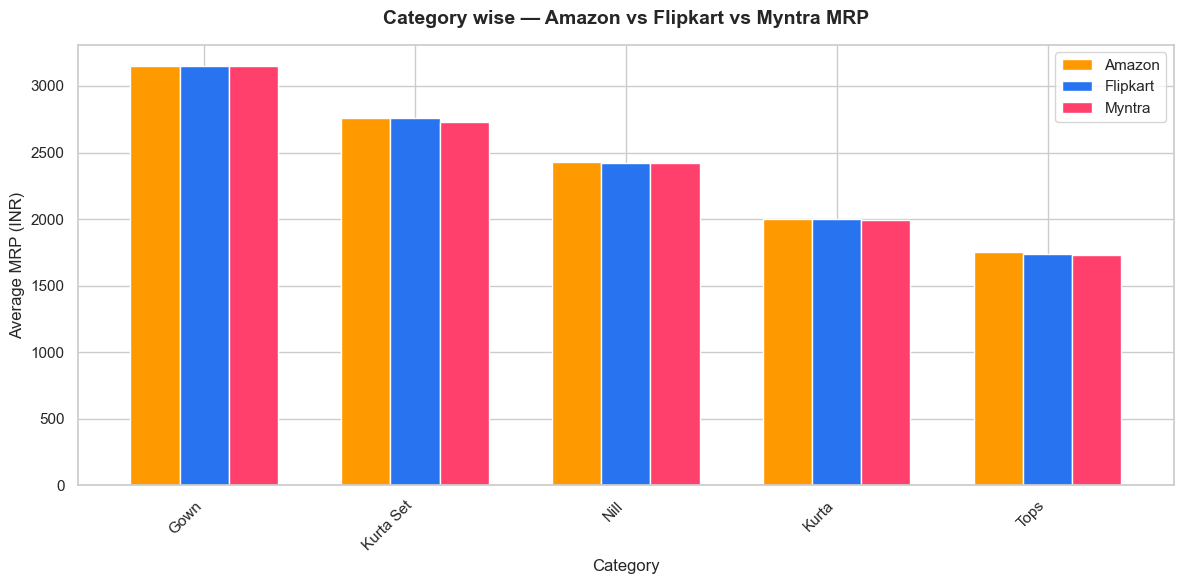

In [9]:
cat_platform = df.groupby('Category')[['Amazon MRP', 'Flipkart MRP', 'Myntra MRP']].mean().round(2)
cat_platform = cat_platform.sort_values('Amazon MRP', ascending=False).head(8)

cat_platform.plot(kind='bar', figsize=(12, 6), 
                  color=['#FF9900', '#2874F0', '#FF3F6C'],
                  edgecolor='white', width=0.7)

plt.title('Category wise — Amazon vs Flipkart vs Myntra MRP', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average MRP (INR)')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.legend(['Amazon', 'Flipkart', 'Myntra'], loc='upper right')
plt.tight_layout()
plt.savefig('../data/chart_category_platform.png', dpi=150)
plt.show()